# 1. Ingesta de datos
## Visualización de datos en la capa Bronze

En la capa Bronze se almacenan los datos crudos del dataset NASA C-MAPSS en su formato original (.txt) dentro de HDFS.  
En esta etapa no se aplican transformaciones, permitiendo mantener una copia íntegra de los datos fuente antes de cualquier proceso de limpieza o estructuración.

In [1]:
from pathlib import Path
sorted([p.name for p in Path("/home/jovyan/work/data/raw").glob("*") if p.is_file()])

['RUL_FD001.txt',
 'RUL_FD002.txt',
 'RUL_FD003.txt',
 'RUL_FD004.txt',
 'test_FD001.txt',
 'test_FD002.txt',
 'test_FD003.txt',
 'test_FD004.txt',
 'train_FD001.txt',
 'train_FD002.txt',
 'train_FD003.txt',
 'train_FD004.txt']

In [1]:
# Crea la sesión spark
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("Proceso NASA") \
    .master("spark://spark-master:7077") \
    .config("spark.executor.cores", "2") \
    .config("spark.cores.max", "2") \
    .config("spark.executor.memory", "1g") \
    .getOrCreate()

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/03/30 23:06:05 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [12]:
fs = spark._jvm.org.apache.hadoop.fs.FileSystem.get(
    spark._jsc.hadoopConfiguration()
)

path = spark._jvm.org.apache.hadoop.fs.Path("/user/root/nasa/bronze")

files = fs.listStatus(path)

for f in files:
    print(f.getPath())

hdfs://namenode:9000/user/root/nasa/bronze/nasa_raw
hdfs://namenode:9000/user/root/nasa/bronze/ros_motor_telemetry


In [15]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import countDistinct, concat_ws, col
from pyspark.sql import functions as F

spark = SparkSession.builder.getOrCreate()

bronze_path = "hdfs://namenode:9000/user/root/nasa/bronze/ros_motor_telemetry"

df = spark.read.parquet(bronze_path)

print("Rows totales en silver:", df.count())

df.groupBy("dataset_id") \
  .agg(
      F.count("*").alias("rows"),
      F.countDistinct("engine_num").alias("motores")
  ) \
  .orderBy("dataset_id") \
  .show()

Rows totales en silver: 75298


+----------+-----+-------+
|dataset_id| rows|motores|
+----------+-----+-------+
|    ROS001|75298|      1|
+----------+-----+-------+



26/04/08 01:34:31 WARN HeartbeatReceiver: Removing executor 8 with no recent heartbeats: 5990868 ms exceeds timeout 120000 ms
26/04/08 01:34:33 ERROR TaskSchedulerImpl: Lost executor 8 on 172.19.0.11: worker lost: Not receiving heartbeat for 60 seconds
26/04/08 16:42:29 ERROR TaskSchedulerImpl: Lost executor 9 on 172.19.0.11: worker lost: Not receiving heartbeat for 60 seconds
26/04/09 17:31:01 WARN HeartbeatReceiver: Removing executor 10 with no recent heartbeats: 294336 ms exceeds timeout 120000 ms
26/04/09 17:31:01 ERROR TaskSchedulerImpl: Lost executor 10 on 172.19.0.11: Executor heartbeat timed out after 294336 ms
26/04/09 17:31:13 ERROR TaskSchedulerImpl: Lost executor 11 on 172.19.0.11: Remote RPC client disassociated. Likely due to containers exceeding thresholds, or network issues. Check driver logs for WARN messages.


## 2. Proceso de Limpieza
# Almacenamiento de datos limpios (Silver)
Tras la etapa de limpieza y preparación con Apache Spark, los datos estructurados se almacenan en la capa Silver del Data Lake en formato Parquet.  
Esta capa contiene los conjuntos `train`, `test` y `RUL` ya preparados para el análisis exploratorio y etapas posteriores del pipeline.

In [5]:
# Visualizar datos procesados 
df_train_all = spark.read.parquet(
"hdfs://namenode:9000/user/root/nasa/silver/ros_motor_telemetry"
)

df_train_all.orderBy("dataset_id","engine_num","cycle").show(193, truncate=False)
df_train_all.count()

+--------------------------+--------------------------+-----------------------+----------+---------+----------+-----+-------------------+---------------------+-------------------+-------------------+-------------------+-------------------+------------------+------------------+------------------+-------------------+-------------------+-------------------+------------------+----------------------+
|timestamp                 |event_ts                  |ingest_ts              |dataset_id|engine_id|engine_num|cycle|op_setting_1       |op_setting_2         |op_setting_3       |sensor_2           |sensor_3           |sensor_4           |sensor_7          |sensor_8          |sensor_9          |sensor_11          |sensor_14          |sensor_15          |sensor_17         |sensor_21             |
+--------------------------+--------------------------+-----------------------+----------+---------+----------+-----+-------------------+---------------------+-------------------+-------------------+---

35650

In [6]:
# Verificar capa Silver
jvm = spark._jvm
conf = spark._jsc.hadoopConfiguration()
fs = jvm.org.apache.hadoop.fs.FileSystem.get(conf)

path = jvm.org.apache.hadoop.fs.Path("hdfs://namenode:9000/user/root/nasa/silver")

for file in fs.listStatus(path):
    print(file.getPath().toString())

hdfs://namenode:9000/user/root/nasa/silver/ros_motor_telemetry
hdfs://namenode:9000/user/root/nasa/silver/rul_FD001
hdfs://namenode:9000/user/root/nasa/silver/rul_FD002
hdfs://namenode:9000/user/root/nasa/silver/rul_FD003
hdfs://namenode:9000/user/root/nasa/silver/rul_FD004
hdfs://namenode:9000/user/root/nasa/silver/test_FD001
hdfs://namenode:9000/user/root/nasa/silver/test_FD002
hdfs://namenode:9000/user/root/nasa/silver/test_FD003
hdfs://namenode:9000/user/root/nasa/silver/test_FD004
hdfs://namenode:9000/user/root/nasa/silver/train_all


In [10]:
path = jvm.org.apache.hadoop.fs.Path("hdfs://namenode:9000/user/root/nasa/silver/train_all")

for file in fs.listStatus(path):
    print(file.getPath().toString())

hdfs://namenode:9000/user/root/nasa/silver/train_all/_SUCCESS
hdfs://namenode:9000/user/root/nasa/silver/train_all/part-00000-d5c7eb64-28b8-436b-bc2f-f8d2274fe407-c000.snappy.parquet
hdfs://namenode:9000/user/root/nasa/silver/train_all/part-00001-d5c7eb64-28b8-436b-bc2f-f8d2274fe407-c000.snappy.parquet
hdfs://namenode:9000/user/root/nasa/silver/train_all/part-00002-d5c7eb64-28b8-436b-bc2f-f8d2274fe407-c000.snappy.parquet
hdfs://namenode:9000/user/root/nasa/silver/train_all/part-00003-d5c7eb64-28b8-436b-bc2f-f8d2274fe407-c000.snappy.parquet
hdfs://namenode:9000/user/root/nasa/silver/train_all/part-00004-d5c7eb64-28b8-436b-bc2f-f8d2274fe407-c000.snappy.parquet
hdfs://namenode:9000/user/root/nasa/silver/train_all/part-00005-d5c7eb64-28b8-436b-bc2f-f8d2274fe407-c000.snappy.parquet


# ANALISIS EXPLORATORIO DE DATOS (EDA)
## 1. Resumen Estadístico 

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
# Convertir a pandas para el análisis
df_pd = df_train_all.toPandas().sort_values(by=["dataset_id","engine_num", "cycle"]).reset_index(drop=True)
# Mostrar en número de motores
engines = df_pd["engine_id"].unique()
print("Total motores:", len(engines))
df_pd.head(193)

Total motores: 709


,dataset_id,engine_id,engine_num,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,FD001,FD001_1,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,...,521.66,2388.02,8138.62,8.4195,0.03,392.0,2388.0,100.0,39.06,23.4190
1,FD001,FD001_1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,...,522.28,2388.07,8131.49,8.4318,0.03,392.0,2388.0,100.0,39.00,23.4236
2,FD001,FD001_1,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,...,522.42,2388.03,8133.23,8.4178,0.03,390.0,2388.0,100.0,38.95,23.3442
3,FD001,FD001_1,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,...,522.86,2388.08,8133.83,8.3682,0.03,392.0,2388.0,100.0,38.88,23.3739
4,FD001,FD001_1,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,...,522.19,2388.04,8133.80,8.4294,0.03,393.0,2388.0,100.0,38.90,23.4044
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
188,FD001,FD001_1,1,189,-0.0006,0.0002,100.0,518.67,644.18,1596.17,...,519.58,2388.33,8117.51,8.5183,0.03,395.0,2388.0,100.0,38.48,23.1127
189,FD001,FD001_1,1,190,-0.0027,0.0001,100.0,518.67,643.64,1599.22,...,520.04,2388.35,8112.58,8.5223,0.03,398.0,2388.0,100.0,38.49,23.0675
190,FD001,FD001_1,1,191,0.0000,-0.0004,100.0,518.67,643.34,1602.36,...,519.57,2388.30,8114.61,8.5174,0.03,394.0,2388.0,100.0,38.45,23.1295
191,FD001,FD001_1,1,192,0.0009,0.0000,100.0,518.67,643.54,1601.41,...,520.08,2388.32,8110.93,8.5113,0.03,396.0,2388.0,100.0,38.48,22.9649


In [10]:
# Identidficación de Variables
df_pd.info()
df_pd.shape

<class 'pandas.DataFrame'>
RangeIndex: 160359 entries, 0 to 160358
Data columns (total 28 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   dataset_id    160359 non-null  str    
 1   engine_id     160359 non-null  str    
 2   engine_num    160359 non-null  int32  
 3   cycle         160359 non-null  int32  
 4   op_setting_1  160359 non-null  float64
 5   op_setting_2  160359 non-null  float64
 6   op_setting_3  160359 non-null  float64
 7   sensor_1      160359 non-null  float64
 8   sensor_2      160359 non-null  float64
 9   sensor_3      160359 non-null  float64
 10  sensor_4      160359 non-null  float64
 11  sensor_5      160359 non-null  float64
 12  sensor_6      160359 non-null  float64
 13  sensor_7      160359 non-null  float64
 14  sensor_8      160359 non-null  float64
 15  sensor_9      160359 non-null  float64
 16  sensor_10     160359 non-null  float64
 17  sensor_11     160359 non-null  float64
 18  sensor_12     1

(160359, 28)

In [12]:
# # Estadístico descriptivos de análisis para detectar escalas distintas.
sensor_cols = [c for c in df_pd.columns if c.startswith("sensor_")]
df_pd[sensor_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
sensor_1,160359.0,485.840890,30.420388,445.0000,449.44000,489.0500,518.6700,518.6700
sensor_2,160359.0,597.361022,42.478516,535.4800,549.96000,605.9300,642.3400,645.1100
sensor_3,160359.0,1467.035653,118.175261,1242.6700,1357.36000,1492.8100,1586.5900,1616.9100
sensor_4,160359.0,1260.956434,136.300073,1023.7700,1126.83000,1271.7400,1402.2000,1441.4900
sensor_5,160359.0,9.894999,4.265554,3.9100,5.48000,9.3500,14.6200,14.6200
sensor_6,160359.0,14.424935,6.443922,5.6700,8.00000,13.6600,21.6100,21.6100
sensor_7,160359.0,359.729968,174.133835,136.1700,175.71000,341.6900,553.2900,570.8100
sensor_8,160359.0,2273.829707,142.426613,1914.7200,2212.12000,2319.3700,2388.0500,2388.6400
sensor_9,160359.0,8677.553696,374.657454,7984.5100,8334.77000,8764.2000,9055.8500,9244.5900
sensor_10,160359.0,1.153705,0.142103,0.9300,1.02000,1.0900,1.3000,1.3200


Se puede observar que existen escalas distintas entre la media y la desviación, lo cual justifica aplicar una normalización para interpretar de mejopr manera el análisis. 

# 2. Normalización: 
se aplicó una normalización estadística a las variables sensoriales con el fin de facilitar la comparación entre señales de diferentes escalas, mejorar la interpretación de las distribuciones y permitir la aplicación de técnicas como el análisis de componentes principales.

In [13]:
# Selección de sensores para normalización
sensor_cols = [c for c in df_pd.columns if c.startswith("sensor_")]
df_eda = df_pd.copy()
# Normalización Global

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_eda[sensor_cols] = scaler.fit_transform(df_eda[sensor_cols])

In [14]:
# Observar datos normalizados
df_eda[sensor_cols].head()

,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1.079185,1.046626,1.037990,1.024534,1.107714,1.115018,1.117707,0.802032,0.983932,1.029505,...,1.113752,0.345200,0.616065,-0.845217,0.963589,1.009022,0.801655,0.345955,1.121962,1.119494
1,1.079185,1.054395,1.055929,1.043169,1.107714,1.115018,1.114204,0.801891,0.978273,1.029505,...,1.117528,0.345649,0.527629,-0.828851,0.963589,1.009022,0.801655,0.345955,1.116830,1.120150
2,1.079185,1.059103,1.023520,1.050946,1.107714,1.115018,1.117133,0.802172,1.001949,1.029505,...,1.118380,0.345289,0.549211,-0.847479,0.963589,0.944550,0.801655,0.345955,1.112553,1.108831
3,1.079185,1.059103,0.979517,1.033851,1.107714,1.115018,1.118224,0.802383,0.992713,1.029505,...,1.121060,0.345739,0.556653,-0.913473,0.963589,1.009022,0.801655,0.345955,1.106566,1.113065
4,1.079185,1.059574,0.980025,1.065766,1.107714,1.115018,1.115640,0.802032,1.007847,1.029505,...,1.116979,0.345379,0.556281,-0.832044,0.963589,1.041258,0.801655,0.345955,1.108277,1.117413


# 2.1. Histogramas Individuales  de variables sensoriales

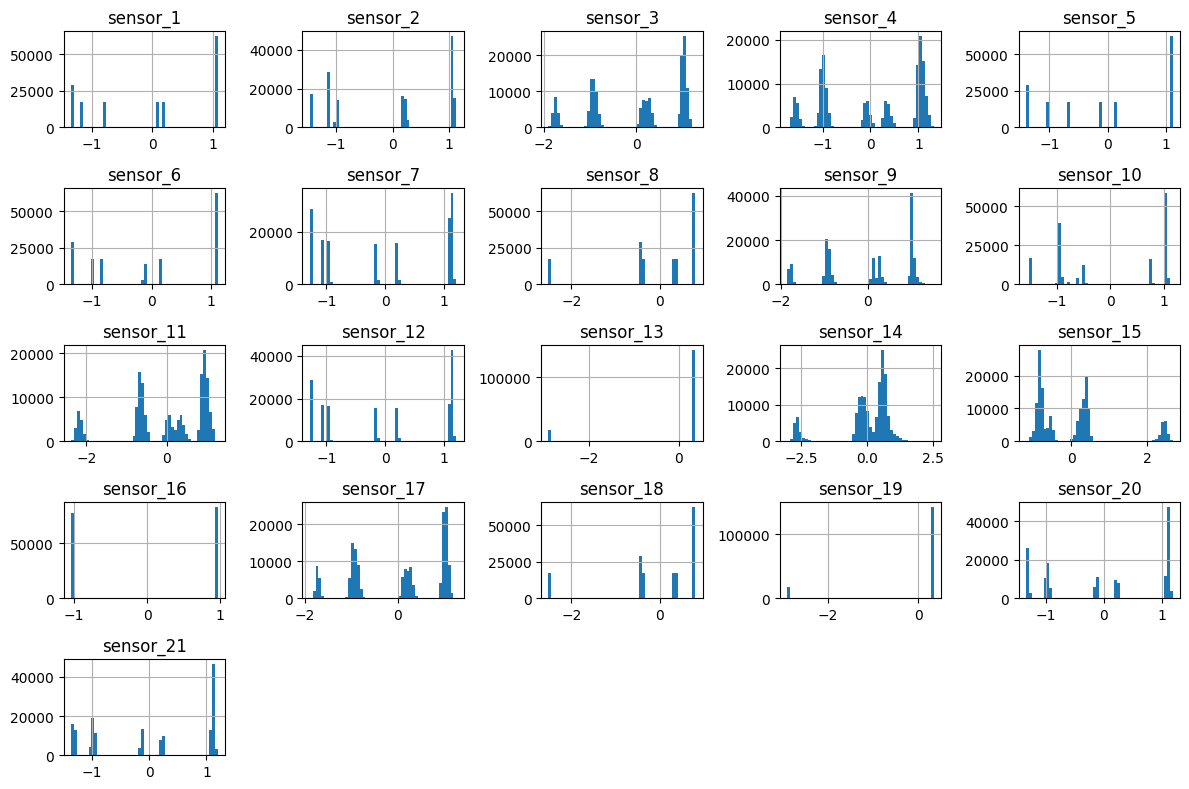

In [15]:
# Diagrama de distribución (Histograma)
sample_sensors = sensor_cols[:21]

df_eda[sample_sensors].hist(
    figsize=(12, 8),
    bins=50
)
plt.tight_layout()
plt.show()

Se puede observar que los sensores no siguen una distribución normal (campana de Gauss). Eso quiere decir que, el comportamiento no es lineal, señales ruidosas.
Distribuciones multimodales osea que presenta varios picos lo que conlleva a diferentes estados del sistema (diferentes regímenes de operación), diferentes fases de degradación.
A simple vista se observa sensores planos: 19, 16, 13.

# 2.2. Matriz de Correlación entre variables.

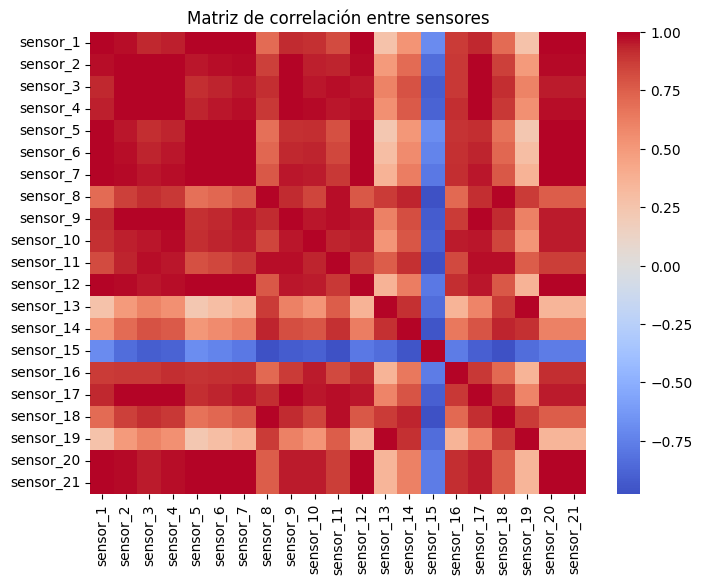

In [16]:
corr = df_eda[sensor_cols].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Matriz de correlación entre sensores")
plt.show()

Se observa una alta correlación positiva entre las variables sensoriales, lo que representa redundancia y que miden fenomenos similares.
Correlación positiva moderada entre sensores 13 y 19: demuestra que miden fenomenos similares pero no con la misma intensidad, lo cual prodría deberse que son valores muy planos.
Correlación negativa fuerte del sensor 15: Al contrario el sensor 15 presenta correlación negativa lo cual implica que es crítico y puede ser usado como; indicador temprano a fallo, degradación.
Implica posible reducción de dimencionalidad y aplicación de PCA (Healt Index) (Análisis de componente principal) para no adivinar que sensor aporta mas que otro devido a su alta correlación.

# 2.3. Aplicación de Varianza
Se aplica la varianza en los datos crudos antes de normalizar, con el objetivo de observar que datos sensoriales no mismo aportan información, osea que a pesar de que trabajen en diferentes escalas, su varianza tienda a 0.
Se usa solo como filtro preliminar para detectar sensores casi constantes.

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sensor_variance = df_pd[sensor_cols].var().sort_values(ascending=False)

sensor_variance

sensor_9     140368.207553
sensor_7      30322.592497
sensor_12     26959.499018
sensor_18     20309.987770
sensor_8      20285.340176
sensor_4      18577.709837
sensor_3      13965.392208
sensor_13     12358.155761
sensor_14      6500.109571
sensor_2       1804.424361
sensor_17       962.329127
sensor_1        925.400015
sensor_20       136.689346
sensor_21        49.211164
sensor_6         41.524136
sensor_19        21.680849
sensor_5         18.194955
sensor_11        11.739821
sensor_15         0.564874
sensor_10         0.020193
sensor_16         0.000025
dtype: float64

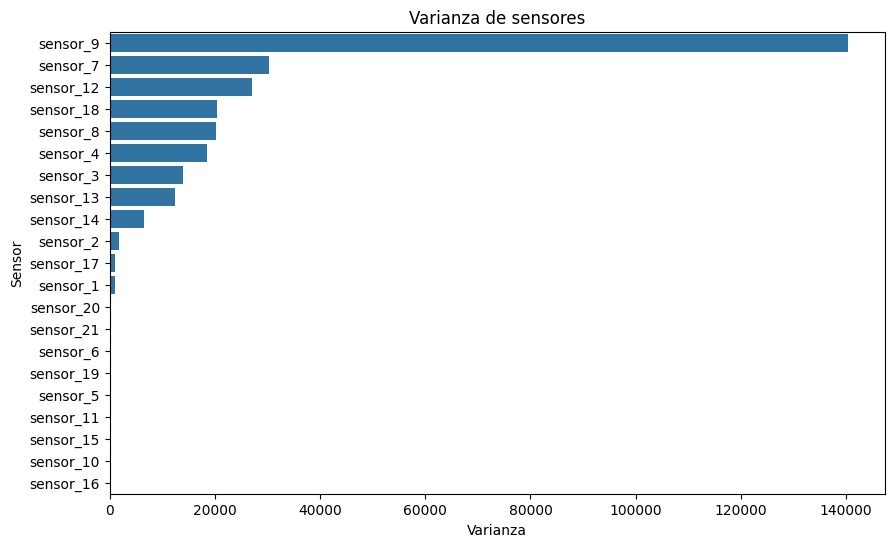

In [18]:
plt.figure(figsize=(10,6))
sns.barplot(x=sensor_variance.values, y=sensor_variance.index)
plt.title("Varianza de sensores")
plt.xlabel("Varianza")
plt.ylabel("Sensor")
plt.show()

Tanto de los resultados numéricos como de la gráfica de varianza se puede observar que a pesar de que trabajen en diferentes escalas, los sensores 16 y 10 son casi constantes (≈ 0), eso quiere decir que no aportarían casi ninguna información de degradación.

# 2.4. Correlación con el ciclo 
sensores que cambian con el ciclo a medida que el motor envejece.
Relación con degradación.

In [269]:
ensor_cols = [c for c in df_eda.columns if "sensor_" in c]

corr_cycle = (
    df_eda[sensor_cols + ["cycle"]]
    .corr()["cycle"]
    .drop("cycle")
    .abs()
    .sort_values(ascending=False)
)

print(corr_cycle)

sensor_14    0.098462
sensor_11    0.043362
sensor_16    0.043034
sensor_4     0.036380
sensor_9     0.033241
sensor_17    0.029852
sensor_3     0.029766
sensor_10    0.017375
sensor_15    0.017034
sensor_12    0.013595
sensor_7     0.013459
sensor_2     0.012651
sensor_21    0.010593
sensor_20    0.010540
sensor_5     0.010034
sensor_1     0.009526
sensor_6     0.009417
sensor_8     0.005933
sensor_18    0.005334
sensor_13    0.001481
sensor_19    0.000687
Name: cycle, dtype: float64


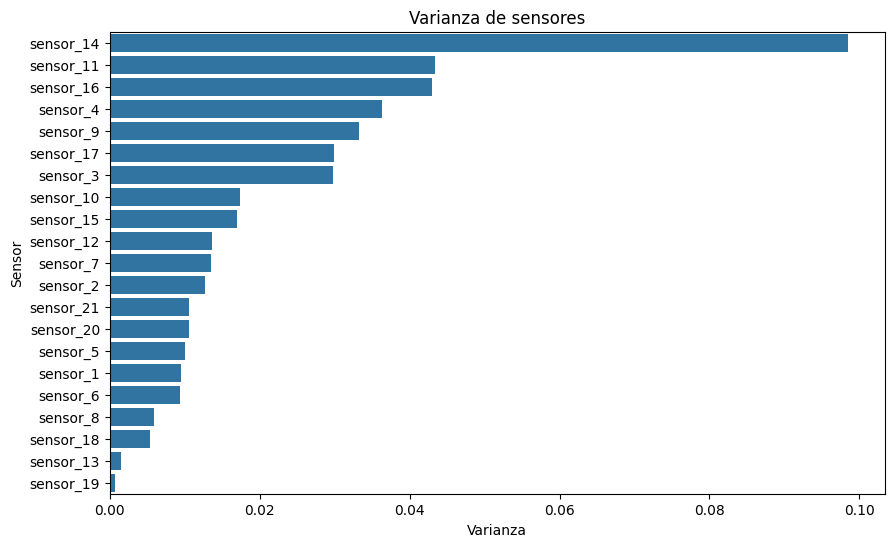

In [270]:
plt.figure(figsize=(10,6))
sns.barplot(x=corr_cycle.values, y=corr_cycle.index)
plt.title("Varianza de sensores")
plt.xlabel("Varianza")
plt.ylabel("Sensor")
plt.show()

Correlación con el ciclo alta: El sensor 16 a pesar de presentar varianza baja y muy poca distribución, presenta una alta correlación con el ciclo. Puede deverse a dos factores, uno a que a pesar de estar en una escala muy baja si representa degradación y otra a cambios de tendencia abruptos (cambio de régimen) lo que justificaría a su varianza baja y poca distribución. Tambien se puede observar los sensores (14,11,4,9,17,3) en este grupo.
Correlación con el ciclo baja: al contrario los sensores 13 y 19 demuestran tener poca información, de acuerdo a las observaciones anteriores y esta. De la misma forma los sensores (1,5,6,8,18).

# 2.4.1. 

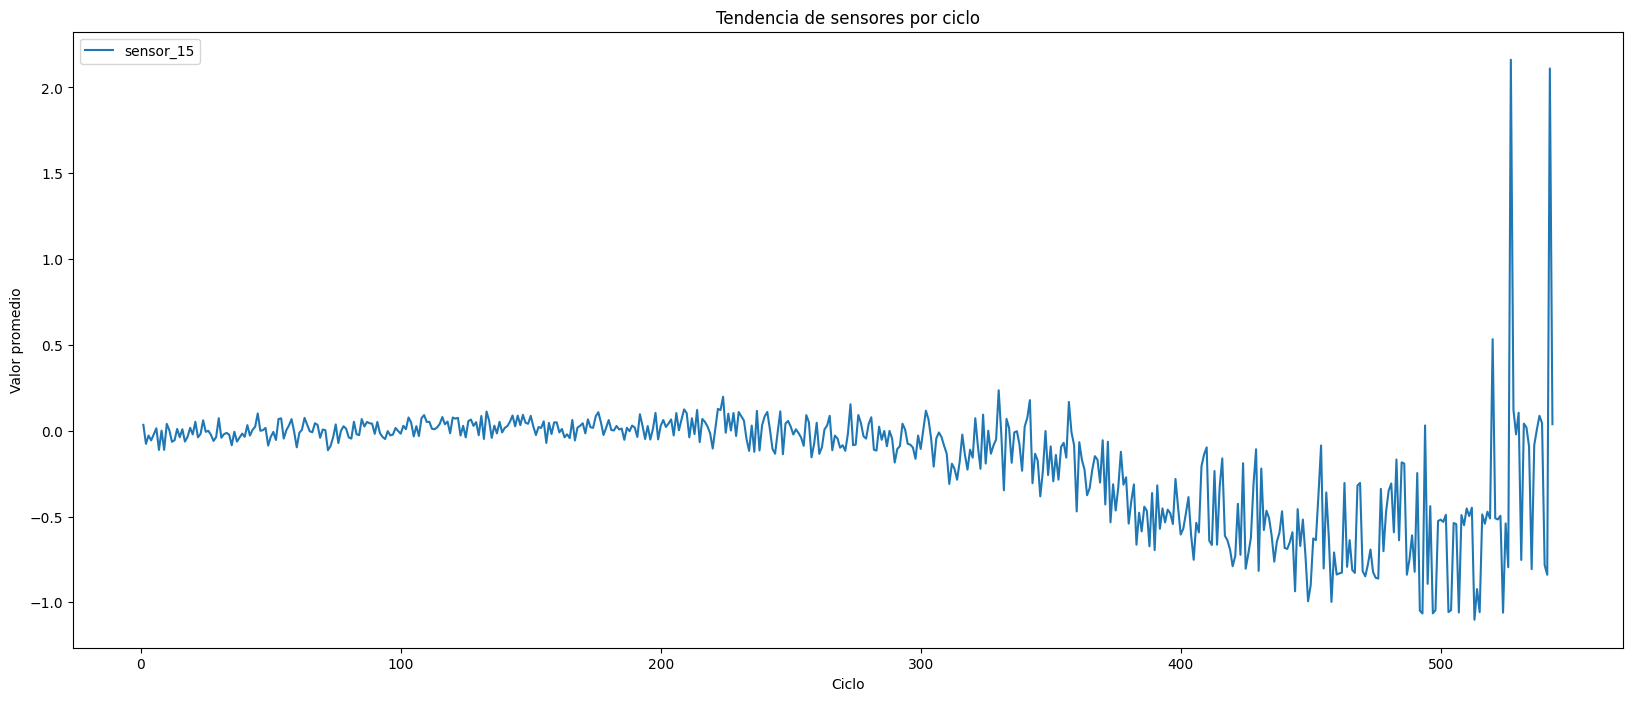

In [383]:
df_cycle = df_eda.groupby("cycle")[sensor_cols].mean()
sensors_plot = ["sensor_15"]

plt.figure(figsize=(20,8))

for s in sensors_plot:
    plt.plot(df_cycle.index, df_cycle[s], label=s)

plt.xlabel("Ciclo")
plt.ylabel("Valor promedio")
plt.title("Tendencia de sensores por ciclo")
plt.legend()
plt.show()

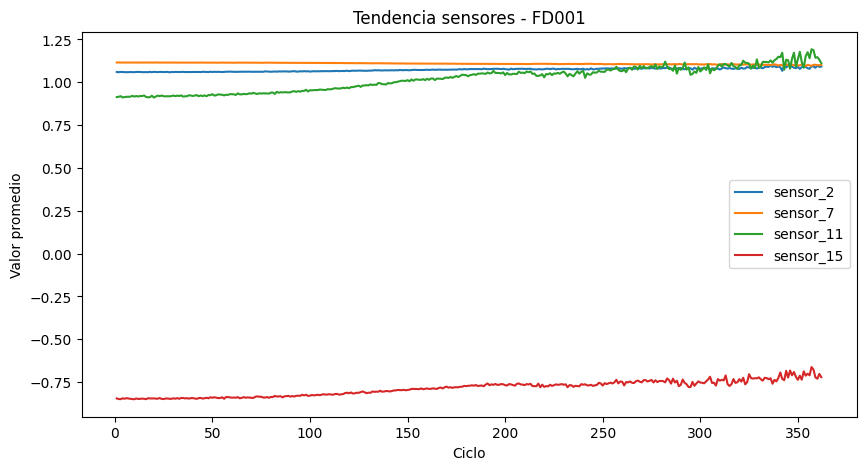

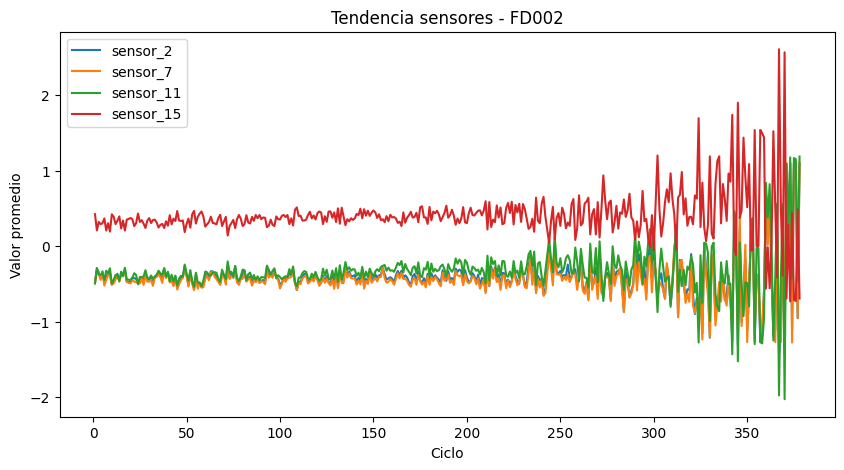

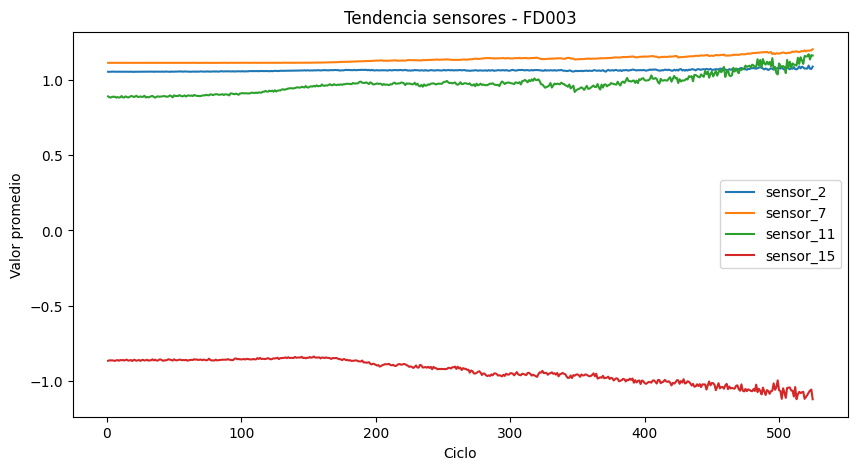

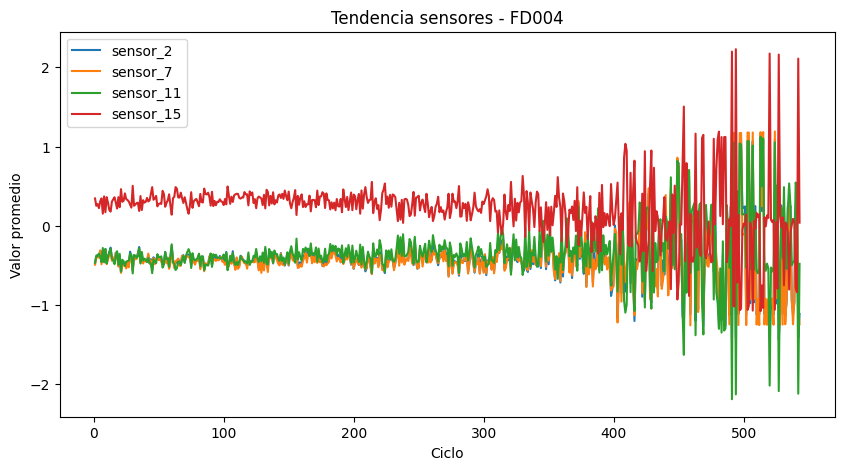

In [384]:
datasets = df_eda["dataset_id"].unique()

sensors_plot = ["sensor_2","sensor_7","sensor_11","sensor_15"]

for ds in datasets:

    df_ds = df_eda[df_eda["dataset_id"] == ds]
    
    df_cycle = df_ds.groupby("cycle")[sensor_cols].mean()
    
    plt.figure(figsize=(10,5))
    
    for s in sensors_plot:
        plt.plot(df_cycle.index, df_cycle[s], label=s)

    plt.xlabel("Ciclo")
    plt.ylabel("Valor promedio")
    plt.title(f"Tendencia sensores - {ds}")
    plt.legend()
    
    plt.show()

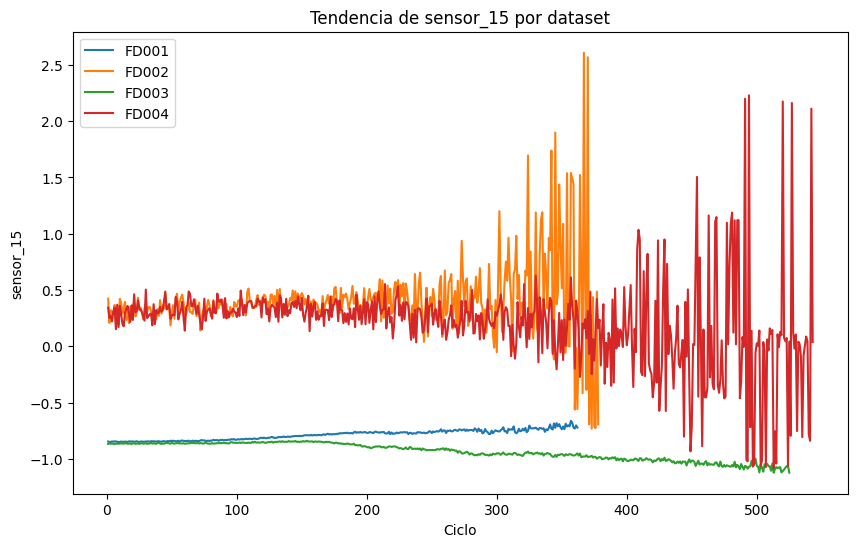

In [385]:
sensor = "sensor_15"

plt.figure(figsize=(10,6))

for ds in df_eda["dataset_id"].unique():

    df_ds = df_eda[df_pd["dataset_id"] == ds]
    
    df_cycle = df_ds.groupby("cycle")[sensor].mean()
    
    plt.plot(df_cycle.index, df_cycle.values, label=ds)

plt.xlabel("Ciclo")
plt.ylabel(sensor)
plt.title(f"Tendencia de {sensor} por dataset")
plt.legend()

plt.show()

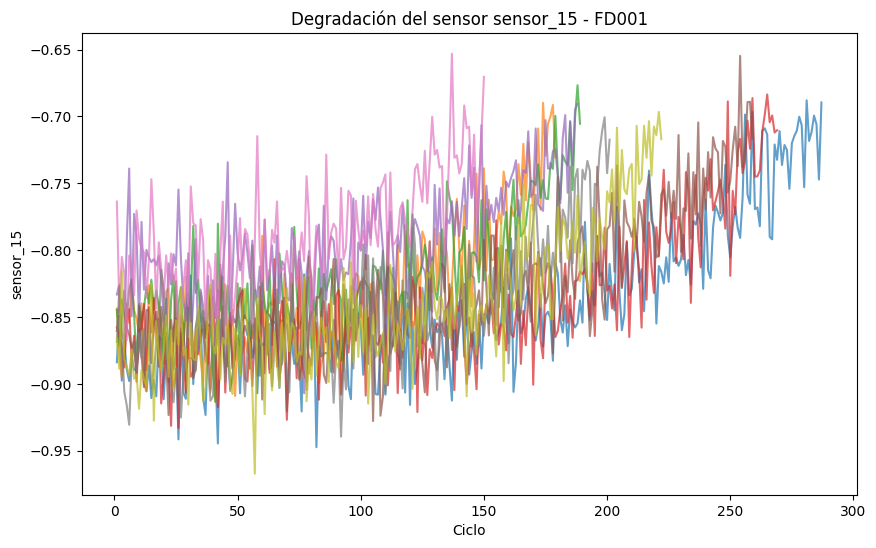

In [387]:
dataset = "FD001"

df_ds = df_eda[df_eda["dataset_id"] == dataset]
sensor = "sensor_15"
engines = df_ds["engine_id"].unique()[1:10]
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

for e in engines:
    
    df_motor = df_ds[df_ds["engine_id"] == e]
    
    plt.plot(df_motor["cycle"], df_motor[sensor], alpha=0.7)

plt.xlabel("Ciclo")
plt.ylabel(sensor)
plt.title(f"Degradación del sensor {sensor} - {dataset}")

plt.show()


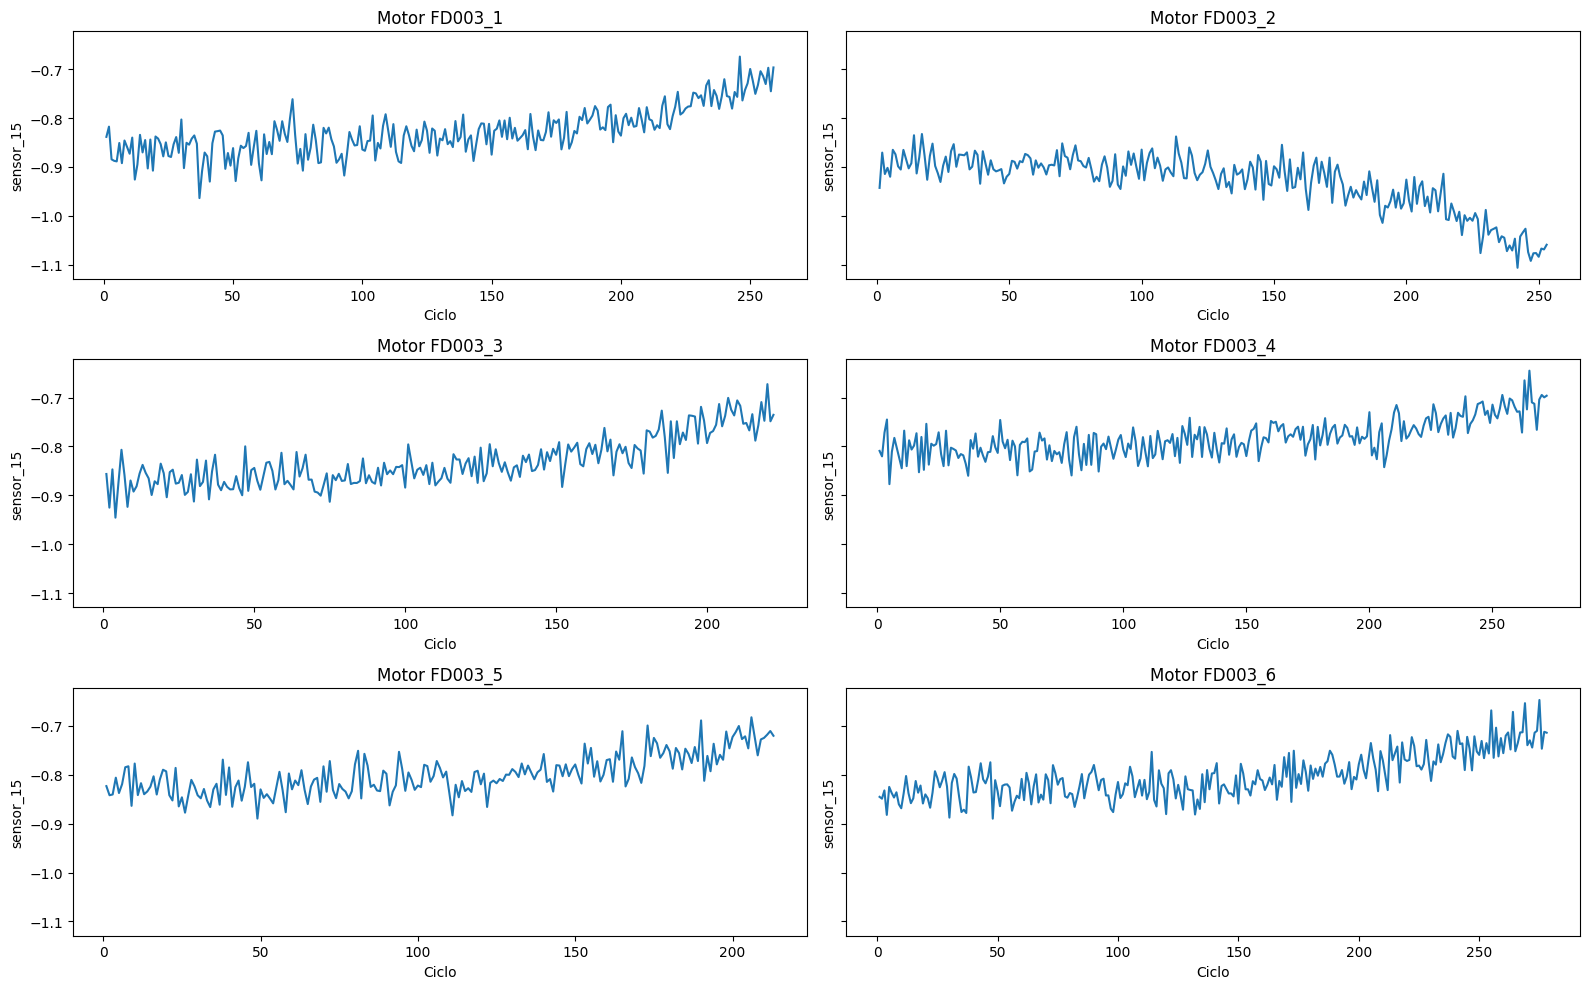

In [388]:
# Evolución temporal
#degradación progresiva, patrones antes de que falle, justificación para el enfoque predictivo.
df_ds = df_eda[df_eda["dataset_id"] == "FD003"]
sensor = "sensor_15"
engines = df_ds["engine_id"].unique()[:6]
fig, axes = plt.subplots(3, 2, figsize=(16, 10), sharey=True)
axes = axes.flatten()
for ax, engine_id in zip(axes, engines):
    df_engine = df_ds[df_ds["engine_id"] == engine_id]
    ax.plot(df_engine["cycle"], df_engine[sensor])
    ax.set_title(f"Motor {engine_id}")
    ax.set_xlabel("Ciclo")
    ax.set_ylabel(sensor)

plt.tight_layout()
plt.show()

<Figure size 1000x400 with 0 Axes>

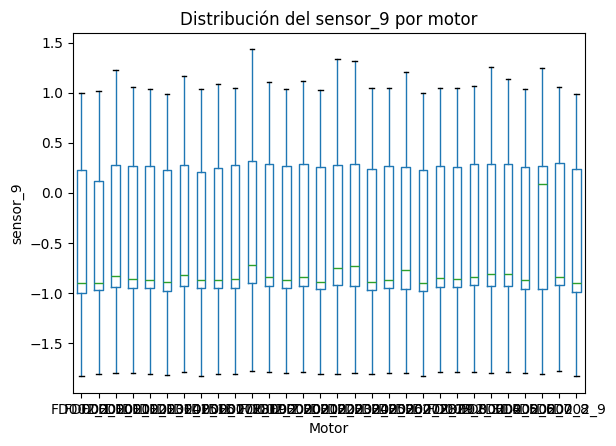

In [308]:
# Grafico de diagrama de caja
# Diferencia en medianas
# Outliers (Puntos negros) y distinatas disperciones
# El sensor 9 no se compara igual en todos los motores
# Presenta valores extremos aislados, que pueden ser candidatos a anomalía
# Motores que muestran mayor variabilidad indican:
# Condiciones anómalas y sensibilidad al desgaste
df_ds = df_eda[df_eda["dataset_id"] == "FD002"]
sensor = "sensor_9"
selected_engines = df_ds["engine_id"].unique()[:30]
df_sel = df_eda[df_eda["engine_id"].isin(selected_engines)]
plt.figure(figsize=(10,4))
df_sel.boxplot(
    column= sensor,
    by="engine_id",
    grid=False
)

plt.xlabel("Motor")
plt.ylabel(sensor)
plt.title("Distribución del "  + str(sensor) + " por motor")
plt.suptitle("")
plt.show()


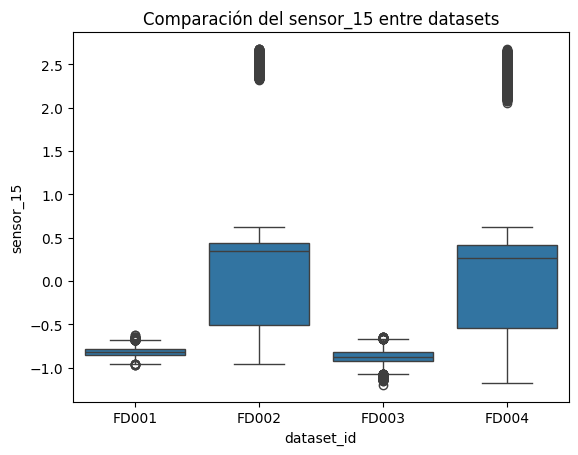

In [389]:
# Comparación entre datasets (FD001–FD004)
#Diferentes condiciones operativas, hay distintos modos de falla, razón por la cual no se normaliza globalmente para ML sino por motor.
sensor= "sensor_15"
sns.boxplot(
    data=df_eda,
    x="dataset_id",
    y=sensor
)
plt.title("Comparación del " + str(sensor) + " entre datasets")
plt.show()

In [175]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

df_pca= df_pd.copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_pca[sensor_cols])
pca = PCA()
X_pca = pca.fit_transform(X_scaled)


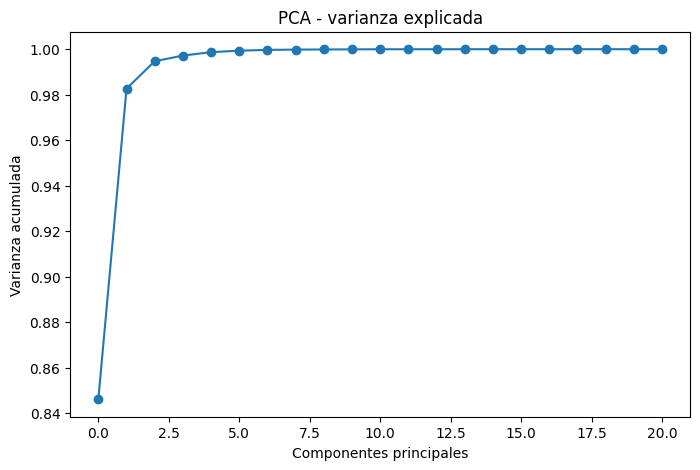

In [319]:
plt.figure(figsize=(8,5))

plt.plot(pca.explained_variance_ratio_.cumsum(), marker='o')

plt.xlabel("Componentes principales")
plt.ylabel("Varianza acumulada")
plt.title("PCA - varianza explicada")

plt.show()

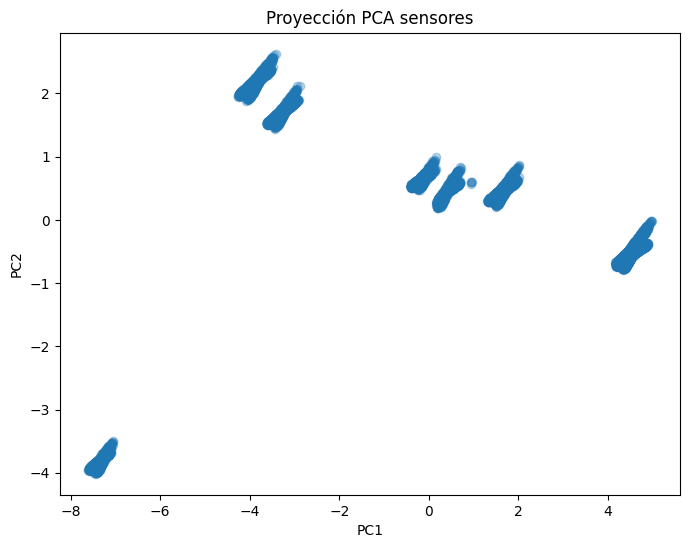

In [318]:
pca_2 = PCA(n_components=2)

X_pca_2 = pca_2.fit_transform(X_scaled)

plt.figure(figsize=(8,6))

plt.scatter(X_pca_2[:,0], X_pca_2[:,1], alpha=0.3)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Proyección PCA sensores")

plt.show()

In [326]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

sensor_cols = [f"sensor_{i}" for i in range(1,22)]

df_pca1=df_pd.copy()

scaler = StandardScaler()

X_scaled = scaler.fit_transform(df_pca1[sensor_cols])

pca = PCA(n_components=1)

df_pca1["health_index"] = pca.fit_transform(X_scaled)

df_pca1[["engine_id","cycle","health_index"]].head()

,engine_id,cycle,health_index
0,FD001_1,1,4.353426
1,FD001_1,2,4.342420
2,FD001_1,3,4.318741
3,FD001_1,4,4.324341
4,FD001_1,5,4.335285


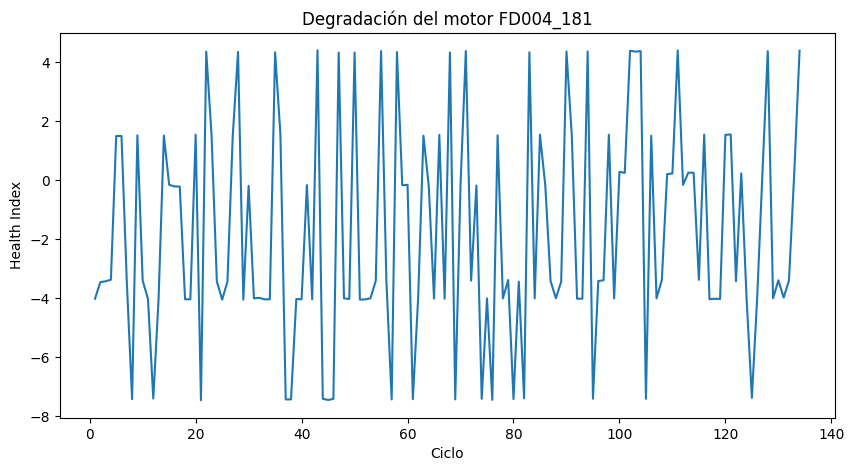

In [350]:
motor = df_pca1["engine_id"].unique()[640]

df_motor = df_pca1[df_pca1["engine_id"] == motor]

plt.figure(figsize=(10,5))

plt.plot(df_motor["cycle"], df_motor["health_index"])

plt.xlabel("Ciclo")
plt.ylabel("Health Index")
plt.title(f"Degradación del motor {motor}")

plt.show()

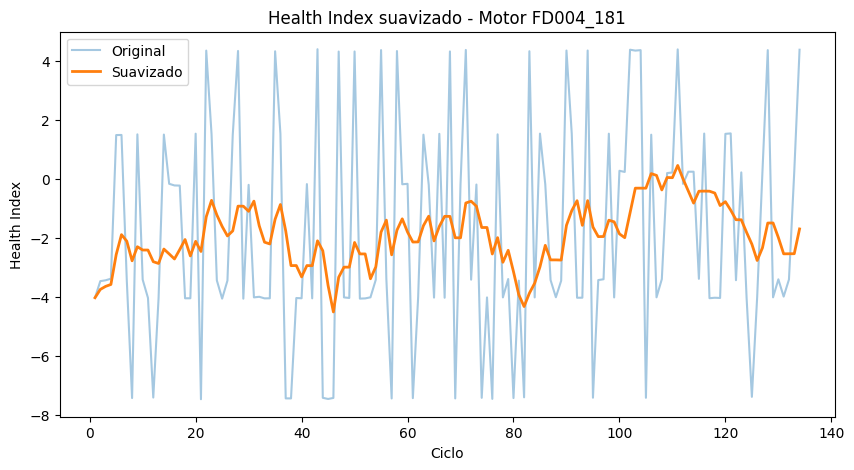

In [390]:
df_pca1["health_index_smooth"] = df_pca1.groupby("engine_id")["health_index"].transform(
    lambda x: x.rolling(window=10, min_periods=1).mean()
)

motor = df_pca1["engine_id"].unique()[640]
df_motor = df_pca1[df_pca1["engine_id"] == motor]

plt.figure(figsize=(10,5))
plt.plot(df_motor["cycle"], df_motor["health_index"], alpha=0.4, label="Original")
plt.plot(df_motor["cycle"], df_motor["health_index_smooth"], linewidth=2, label="Suavizado")
plt.xlabel("Ciclo")
plt.ylabel("Health Index")
plt.title(f"Health Index suavizado - Motor {motor}")
plt.legend()
plt.show()

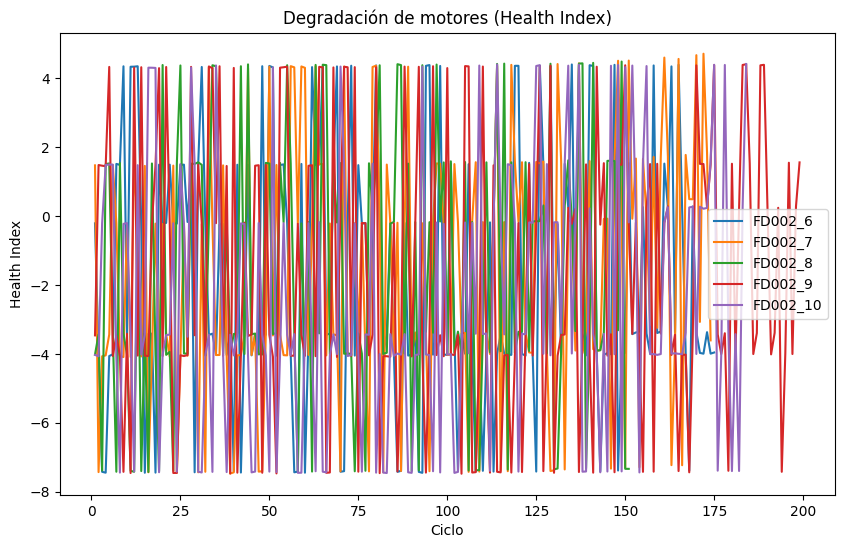

In [358]:
motores = df_pca1["engine_id"].unique()[105:110]

plt.figure(figsize=(10,6))

for m in motores:
    
    df_motor = df_pca1[df_pca1["engine_id"] == m]
    
    plt.plot(df_motor["cycle"], df_motor["health_index"], label=m)

plt.xlabel("Ciclo")
plt.ylabel("Health Index")
plt.title("Degradación de motores (Health Index)")
plt.legend()

plt.show()

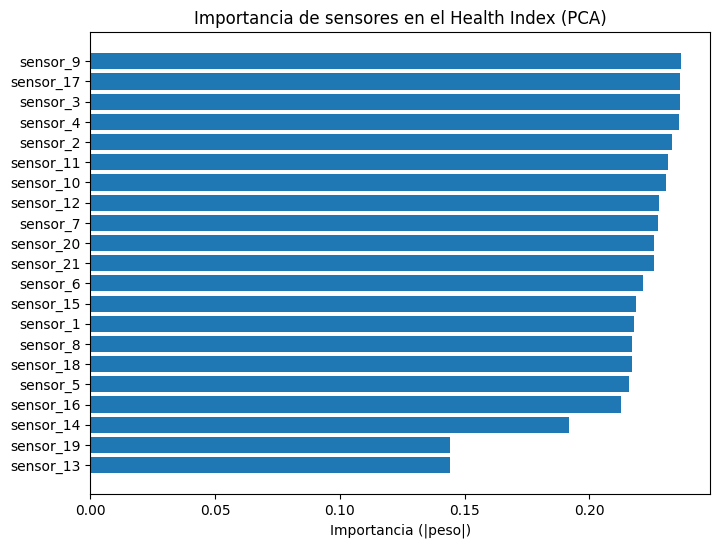

,sensor,weight,abs_weight
8,sensor_9,0.236634,0.236634
16,sensor_17,0.236535,0.236535
2,sensor_3,0.236511,0.236511
3,sensor_4,0.235970,0.235970
1,sensor_2,0.233349,0.233349
10,sensor_11,0.231457,0.231457
9,sensor_10,0.230917,0.230917
11,sensor_12,0.227761,0.227761
6,sensor_7,0.227693,0.227693
19,sensor_20,0.226107,0.226107


In [361]:
# Extraer los pesos de los sensores
import pandas as pd

loadings = pd.DataFrame({
    "sensor": sensor_cols,
    "weight": pca.components_[0]
})
# Ordenar sensores por importancia
loadings["abs_weight"] = loadings["weight"].abs()

loadings_sorted = loadings.sort_values(
    by="abs_weight",
    ascending=False
)

# Visualización
plt.figure(figsize=(8,6))
plt.barh(
    loadings_sorted["sensor"],
    loadings_sorted["abs_weight"]
)
plt.gca().invert_yaxis()
plt.xlabel("Importancia (|peso|)")
plt.title("Importancia de sensores en el Health Index (PCA)")
plt.show()

loadings_sorted

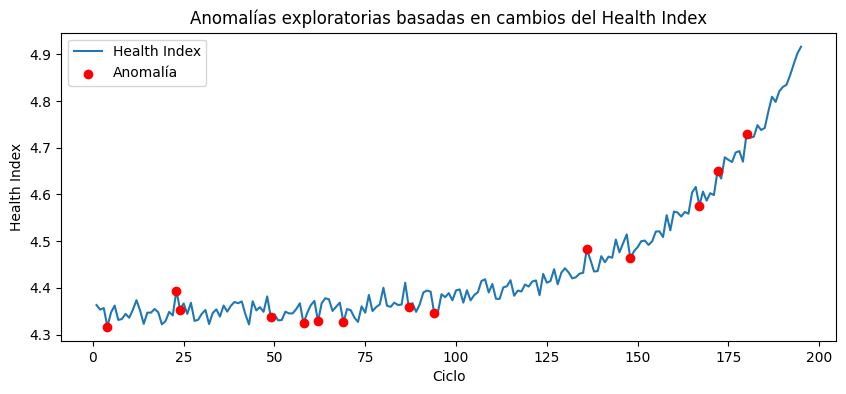

In [394]:
# Elección del motor
engine_1 = df_pca1[df_eda["engine_id"] == "FD001_18"].copy()

engine_1["hi_diff"] = engine_1["health_index"].diff()

# Se define anomalías por cambio brusco usando percentiles (Degradación Progresiva)
upper = engine_1["hi_diff"].quantile(0.98)
lower = engine_1["hi_diff"].quantile(0.05)

engine_1["anomaly"] = (
    (engine_1["hi_diff"] > upper) |
    (engine_1["hi_diff"] < lower)
)

# Visualización 
plt.figure(figsize=(10,4))

plt.plot(
    engine_1["cycle"],
    engine_1["health_index"],
    label="Health Index"
)

plt.scatter(
    engine_1.loc[engine_1["anomaly"], "cycle"],
    engine_1.loc[engine_1["anomaly"], "health_index"],
    color="red",
    label="Anomalía",
    zorder=3
)

plt.xlabel("Ciclo")
plt.ylabel("Health Index")
plt.title("Anomalías exploratorias basadas en cambios del Health Index")
plt.legend()
plt.show()

In [375]:
from sklearn.model_selection import train_test_split

train_engines, test_engines = train_test_split(
    engines,
    test_size=0.2,
    random_state=42
)

train_df = df_pd[df_pd["engine_id"].isin(train_engines)]
test_df = df_pd[df_pd["engine_id"].isin(test_engines)]

print("Motores entrenamiento:", len(train_engines))
print("Motores test:", len(test_engines))

set(train_engines).intersection(set(test_engines))

Motores entrenamiento: 567
Motores test: 142


set()

In [376]:
df_v= df_pd
life_per_engine = (
    df_v.groupby("engine_id")["cycle"]
    .max()
    .sort_values()
)

life_per_engine.describe()

count    709.000000
mean     226.176305
std       66.434783
min      128.000000
25%      181.000000
50%      207.000000
75%      259.000000
max      543.000000
Name: cycle, dtype: float64

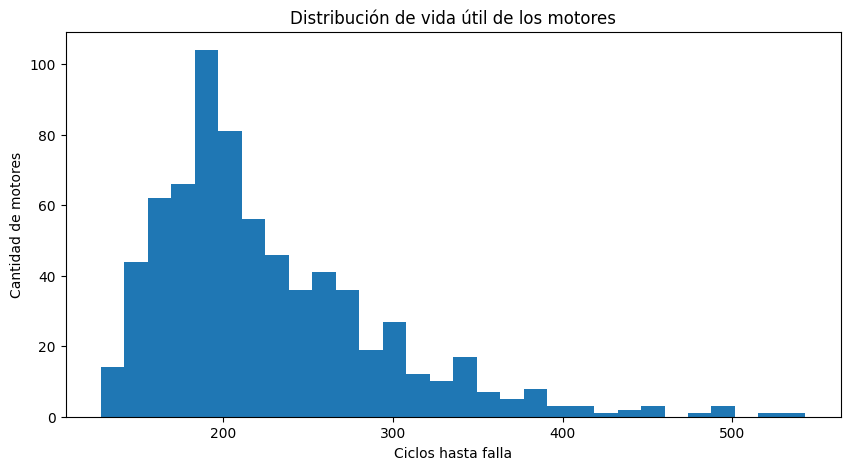

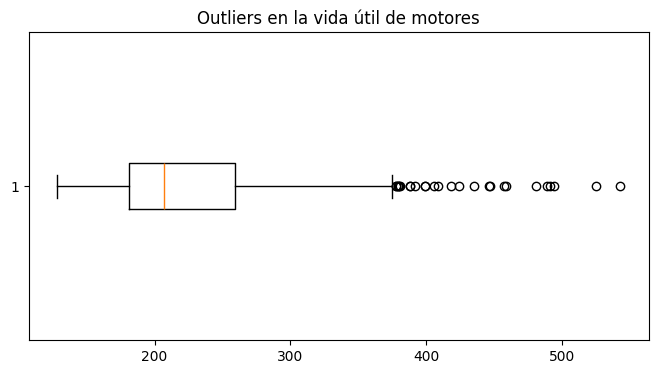

In [378]:

plt.figure(figsize=(10,5))
plt.hist(life_per_engine, bins=30)
plt.xlabel("Ciclos hasta falla")
plt.ylabel("Cantidad de motores")
plt.title("Distribución de vida útil de los motores")
plt.show()

plt.figure(figsize=(8,4))
plt.boxplot(life_per_engine, vert=False)
plt.title("Outliers en la vida útil de motores")
plt.show()

In [381]:
df_pd[["op_setting_1","op_setting_2","op_setting_3"]].describe()

,op_setting_1,op_setting_2,op_setting_3
count,160359.000000,160359.000000,160359.000000
mean,17.211973,0.410004,95.724344
std,16.527988,0.367938,12.359044
min,-0.008700,-0.000600,60.000000
25%,0.001300,0.000200,100.000000
50%,19.998100,0.620000,100.000000
75%,35.001500,0.840000,100.000000
max,42.008000,0.842000,100.000000


In [382]:
df_pd.groupby("dataset_id")[["op_setting_1","op_setting_2","op_setting_3"]].agg(["mean","std","min","max"])

op_setting_1                             op_setting_2                           op_setting_3                         
                   mean        std     min      max         mean       std     min     max         mean        std    min    max
dataset_id                                                                                                                      
FD001         -0.000009   0.002187 -0.0087   0.0087     0.000002  0.000293 -0.0006  0.0006   100.000000   0.000000  100.0  100.0
FD002         23.998407  14.747376  0.0000  42.0080     0.572056  0.310016  0.0000  0.8420    94.046020  14.237735   60.0  100.0
FD003         -0.000024   0.002194 -0.0086   0.0086     0.000005  0.000294 -0.0006  0.0007   100.000000   0.000000  100.0  100.0
FD004         23.999823  14.780722  0.0000  42.0080     0.571347  0.310703  0.0000  0.8420    94.031576  14.251954   60.0  100.0

# 3. Preprocesamiento

In [ ]:
from pyspark.sql import SparkSession

spark = SparkSession.builder.getOrCreate()

df = spark.read.parquet("hdfs://namenode:9000/user/root/nasa/gold/train_gold")

df.show(5)
df.printSchema()
df.count()

+----------+---------+----------+-----+--------+--------+--------+---------+---------+---------+--------+--------+---------+--------+---------+------------+------------+------------+
|dataset_id|engine_id|engine_num|cycle|sensor_9|sensor_4|sensor_3|sensor_17|sensor_11|sensor_14|sensor_8|sensor_7|sensor_21|sensor_2|sensor_15|op_setting_1|op_setting_2|op_setting_3|
+----------+---------+----------+-----+--------+--------+--------+---------+---------+---------+--------+--------+---------+--------+---------+------------+------------+------------+
|     FD004|FD004_240|       240|   51| 8007.66| 1046.76| 1267.18|    304.0|    36.72|  7868.65| 1915.32|  175.89|   8.6494|  536.81|  10.9269|     25.0063|        0.62|        60.0|
|     FD004|FD004_240|       240|   52| 8345.47| 1124.02| 1356.99|    334.0|    41.79|  8062.11|  2222.9|  194.69|   9.0359|  555.52|   9.2931|     34.9997|      0.8417|       100.0|
|     FD004|FD004_240|       240|   53|  8723.0| 1237.22| 1486.29|    366.0|    44.23

160359

26/03/21 17:52:34 ERROR TaskSchedulerImpl: Lost executor 0 on 172.19.0.9: worker lost: Not receiving heartbeat for 60 seconds
26/03/21 19:09:10 ERROR TaskSchedulerImpl: Lost executor 1 on 172.19.0.9: worker lost: Not receiving heartbeat for 60 seconds
26/03/21 23:03:41 ERROR StandaloneSchedulerBackend: Application has been killed. Reason: Master removed our application: KILLED
26/03/21 23:03:42 ERROR Inbox: Ignoring error
org.apache.spark.SparkException: Exiting due to error from cluster scheduler: Master removed our application: KILLED
	at org.apache.spark.errors.SparkCoreErrors$.clusterSchedulerError(SparkCoreErrors.scala:291)
	at org.apache.spark.scheduler.TaskSchedulerImpl.error(TaskSchedulerImpl.scala:981)
	at org.apache.spark.scheduler.cluster.StandaloneSchedulerBackend.dead(StandaloneSchedulerBackend.scala:165)
	at org.apache.spark.deploy.client.StandaloneAppClient$ClientEndpoint.markDead(StandaloneAppClient.scala:263)
	at org.apache.spark.deploy.client.StandaloneAppClient$Clien

In [17]:
df.orderBy("dataset_id","engine_num","cycle").show(193)

+----------+---------+----------+-----+--------+--------+--------+---------+---------+---------+--------+--------+---------+--------+---------+------------+------------+------------+
|dataset_id|engine_id|engine_num|cycle|sensor_9|sensor_4|sensor_3|sensor_17|sensor_11|sensor_14|sensor_8|sensor_7|sensor_21|sensor_2|sensor_15|op_setting_1|op_setting_2|op_setting_3|
+----------+---------+----------+-----+--------+--------+--------+---------+---------+---------+--------+--------+---------+--------+---------+------------+------------+------------+
|     FD001|  FD001_1|         1|    1| 9046.19|  1400.6|  1589.7|    392.0|    47.47|  8138.62| 2388.06|  554.36|   23.419|  641.82|   8.4195|     -7.0E-4|     -4.0E-4|       100.0|
|     FD001|  FD001_1|         1|    2| 9044.07| 1403.14| 1591.82|    392.0|    47.49|  8131.49| 2388.04|  553.75|  23.4236|  642.15|   8.4318|      0.0019|     -3.0E-4|       100.0|
|     FD001|  FD001_1|         1|    3| 9052.94|  1404.2| 1587.99|    390.0|    47.27